**Customer Segmentation Using K-Means Clustering**

**Problem Statement**

The objective of this project is to segment customers into different groups based on their purchasing behavior so that businesses can target them with personalized marketing strategies.



In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0



  -The dataset contains 200 customer records.

  
  -There are 5 columns: CustomerID, Gender, Age, Annual Income, and Spending Score.

  
  -No missing values were found in the dataset.

  
  -The data is clean and ready for analysis.


**Distribution of Income**

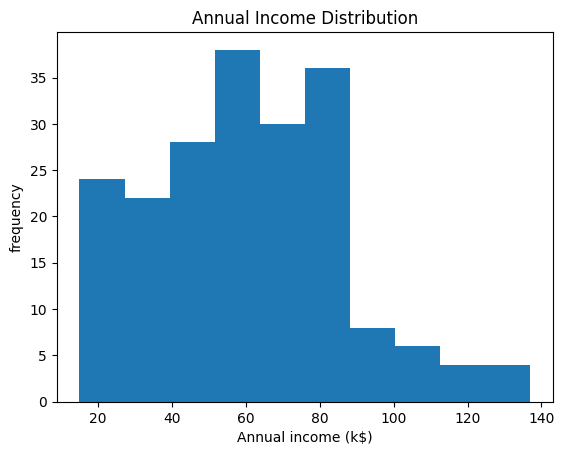

In [6]:
plt.hist(df['Annual Income (k$)'])
plt.xlabel("Annual income (k$)")
plt.ylabel("frequency")
plt.title("Annual Income Distribution")
plt.show()

-	Annual income ranges approximately from 15k to 137k.

-	Most customers fall in the mid-income category.

-	There are fewer customers in extreme high-income range.


**Distribution of Spending Score**

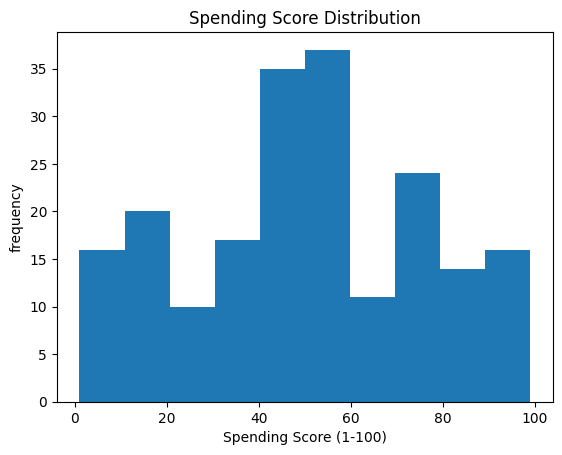

In [7]:
plt.hist(df['Spending Score (1-100)'])
plt.xlabel("Spending Score (1-100)")
plt.ylabel("frequency")
plt.title("Spending Score Distribution")
plt.show()

•	Spending score ranges from 1 to 100.

•	Customers are distributed across low, medium, and high spending categories.

•	This suggests varied purchasing behavior.


**Relationship between them.**

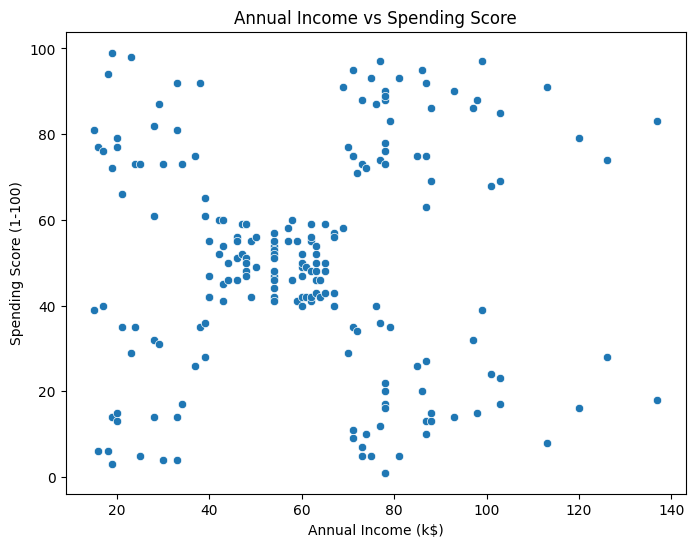

In [8]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)']
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")

plt.show()


•	Customers with similar income levels show different spending behaviors.

•	Some high-income customers have low spending scores.

•	Some low-income customers have high spending scores.

•	This indicates that income alone does not determine spending behavior.

•	Clustering is suitable to identify hidden patterns.


**Feature Selection**

In [9]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

•	Annual Income and Spending Score were selected as key features.

•	These two features directly represent purchasing power and buying behavior.

•	They are sufficient to perform meaningful customer segmentation.


**Feature Scaling**

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

•	Feature scaling was applied to standardize the data.

•	Since K-Means uses distance calculations, scaling ensures that one feature does not dominate the clustering process.

•	This improves clustering accuracy.


**Elbow Method**

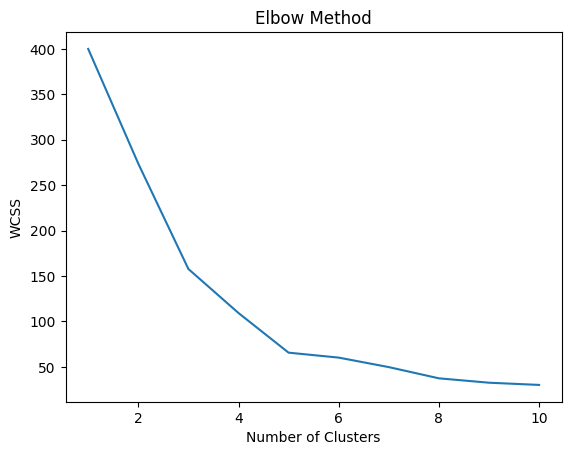

In [11]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

•	The Elbow Method was used to determine the optimal number of clusters.

•	The graph shows a clear bend at k = 5.

•	This indicates that 5 clusters provide a good balance between compactness and simplicity.


**K-Means**

In [12]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

•	K-Means clustering was applied with 5 clusters.

•	Each customer was assigned to one of the five segments.

•	The algorithm grouped customers based on similarity in income and spending behavior.


**Visualize Clusters**

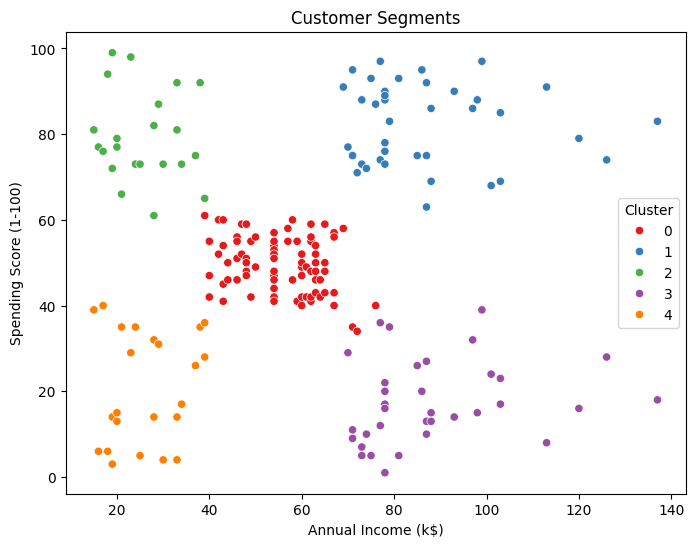

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['Cluster'],
    palette='Set1'
)
plt.title("Customer Segments")
plt.show()

•	The visualization clearly shows five distinct customer segments.

•	Each cluster represents a unique purchasing pattern.

•	Customers within the same cluster show similar behavior.


Cluster 0 → High Income, High Spending → Premium Customers

Cluster 1 → High Income, Low Spending → Careful Rich

Cluster 2 → Low Income, High Spending → Impulsive Buyers

Cluster 3 → Low Income, Low Spending → Budget Customers

Cluster 4 → Medium Income, Medium Spending → Regular Customers

**Conclusion**

The project successfully segmented customers into meaningful groups using K-Means clustering. These segments help businesses make data-driven marketing decisions and improve revenue.